In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glob
from pathlib import Path
from tqdm import tqdm

In [4]:
# ============================================================
# 👉 MODIFIE CES CHEMINS selon ton organisation
TRAIN_DIR = '../climatenet/train/'
TEST_DIR  = '../climatenet/test/'
# ============================================================
 
SHAPE = (768, 1152)

In [5]:
# ============================================================
# ÉTAPE 1 — Chargement des matrices train déjà calculées
#            (ou recalcul si pas encore fait)
# ============================================================
try:
    count_tc_train = np.load('count_tc.npy')
    count_ar_train = np.load('count_ar.npy')
    print('✅ Matrices train chargées depuis count_tc.npy / count_ar.npy')
    n_train = len(sorted(glob.glob(f'{TRAIN_DIR}*.nc')))
except FileNotFoundError:
    print('⚠️  Matrices train non trouvées — recalcul en cours...')
    files_train = sorted(glob.glob(f'{TRAIN_DIR}*.nc'))
    n_train = len(files_train)
    count_tc_train = np.zeros(SHAPE, dtype=np.int32)
    count_ar_train = np.zeros(SHAPE, dtype=np.int32)
    for f in tqdm(files_train, desc='Train'):
        ds = xr.open_dataset(f)
        labels = ds['LABELS'].values
        ds.close()
        count_tc_train += (labels == 1).astype(np.int32)
        count_ar_train += (labels == 2).astype(np.int32)
    np.save('count_tc.npy', count_tc_train)
    np.save('count_ar.npy', count_ar_train)
    print(f'✅ Recalcul terminé ({n_train} fichiers)')

✅ Matrices train chargées depuis count_tc.npy / count_ar.npy


In [6]:
# ============================================================
# ÉTAPE 2 — Accumulation sur les fichiers TEST
# ============================================================
files_test = sorted(glob.glob(f'{TEST_DIR}*.nc'))
n_test = len(files_test)
print(f'\nNombre de fichiers test trouvés : {n_test}')
 
count_tc_test = np.zeros(SHAPE, dtype=np.int32)
count_ar_test = np.zeros(SHAPE, dtype=np.int32)
 
for f in tqdm(files_test, desc='Accumulation test'):
    ds = xr.open_dataset(f)
    labels = ds['LABELS'].values
    ds.close()
    count_tc_test += (labels == 1).astype(np.int32)
    count_ar_test += (labels == 2).astype(np.int32)
 
np.save('count_tc_test.npy', count_tc_test)
np.save('count_ar_test.npy', count_ar_test)
print('✅ Matrices test sauvegardées')


Nombre de fichiers test trouvés : 61


Accumulation test: 100%|██████████| 61/61 [00:00<00:00, 89.03it/s]

✅ Matrices test sauvegardées


In [7]:
# ============================================================
# ÉTAPE 3 — Résumé statistique test
# ============================================================
total_pixels = SHAPE[0] * SHAPE[1]
 
never_tc_test  = count_tc_test == 0
never_ar_test  = count_ar_test == 0
never_event_test = never_tc_test & never_ar_test
 
print()
print('=' * 55)
print('RÉSUMÉ TEST')
print('=' * 55)
print(f'Total pixels par grille       : {total_pixels:>10,}')
print(f'Jamais TC  (sur {n_test} fichiers) : {never_tc_test.sum():>10,}  ({100*never_tc_test.mean():.1f}%)')
print(f'Jamais AR  (sur {n_test} fichiers) : {never_ar_test.sum():>10,}  ({100*never_ar_test.mean():.1f}%)')
print(f'Jamais TC ni AR               : {never_event_test.sum():>10,}  ({100*never_event_test.mean():.1f}%)')
print(f'Pixel le plus souvent TC      : {count_tc_test.max()} fois / {n_test} ({100*count_tc_test.max()/n_test:.1f}%)')
print(f'Pixel le plus souvent AR      : {count_ar_test.max()} fois / {n_test} ({100*count_ar_test.max()/n_test:.1f}%)')


RÉSUMÉ TEST
Total pixels par grille       :    884,736
Jamais TC  (sur 61 fichiers) :    786,212  (88.9%)
Jamais AR  (sur 61 fichiers) :    477,240  (53.9%)
Jamais TC ni AR               :    434,593  (49.1%)
Pixel le plus souvent TC      : 13 fois / 61 (21.3%)
Pixel le plus souvent AR      : 30 fois / 61 (49.2%)


In [8]:
# ============================================================
# ÉTAPE 4 — Comparaison Train vs Test
# ============================================================
never_event_train = (count_tc_train == 0) & (count_ar_train == 0)
 
# Zones mortes dans train mais ACTIVES dans test → danger !
dead_in_train_active_in_test = never_event_train & ~never_event_test
# Zones mortes dans les deux → masque sûr
safe_mask = never_event_train & never_event_test
# Zones actives dans train mais mortes dans test
active_train_dead_test = ~never_event_train & never_event_test
 
print()
print('=' * 55)
print('COMPARAISON TRAIN vs TEST')
print('=' * 55)
print(f'Zones mortes dans TRAIN         : {never_event_train.sum():>8,}  ({100*never_event_train.mean():.1f}%)')
print(f'Zones mortes dans TEST          : {never_event_test.sum():>8,}  ({100*never_event_test.mean():.1f}%)')
print()
print(f'✅ Zones mortes dans les DEUX   : {safe_mask.sum():>8,}  ({100*safe_mask.mean():.1f}%)  ← masque sûr')
print(f'⚠️  Mortes train / Actives test  : {dead_in_train_active_in_test.sum():>8,}  ({100*dead_in_train_active_in_test.mean():.1f}%)  ← RISQUE')
print(f'ℹ️  Actives train / Mortes test  : {active_train_dead_test.sum():>8,}  ({100*active_train_dead_test.mean():.1f}%)')
print()
 
if dead_in_train_active_in_test.sum() == 0:
    print('🎉 AUCUN RISQUE — Le masque train couvre parfaitement le test !')
    print(f'   → On peut masquer {100*safe_mask.mean():.1f}% des pixels en toute sécurité')
else:
    print(f'⚠️  ATTENTION — {dead_in_train_active_in_test.sum():,} pixels sont actifs en test')
    print(f'   mais jamais vus en train → le masque train serait dangereux !')
    print(f'   → Utilise le masque INTERSECTION (safe_mask) à la place')
 
# Sauvegarde du masque sûr
np.save('safe_mask.npy', safe_mask)
np.save('dead_in_train_active_in_test.npy', dead_in_train_active_in_test)
print(f'\n💾 Masque sûr sauvegardé dans safe_mask.npy')


COMPARAISON TRAIN vs TEST
Zones mortes dans TRAIN         :  247,154  (27.9%)
Zones mortes dans TEST          :  434,593  (49.1%)

✅ Zones mortes dans les DEUX   :  238,991  (27.0%)  ← masque sûr
⚠️  Mortes train / Actives test  :    8,163  (0.9%)  ← RISQUE
ℹ️  Actives train / Mortes test  :  195,602  (22.1%)

⚠️  ATTENTION — 8,163 pixels sont actifs en test
   mais jamais vus en train → le masque train serait dangereux !
   → Utilise le masque INTERSECTION (safe_mask) à la place

💾 Masque sûr sauvegardé dans safe_mask.npy


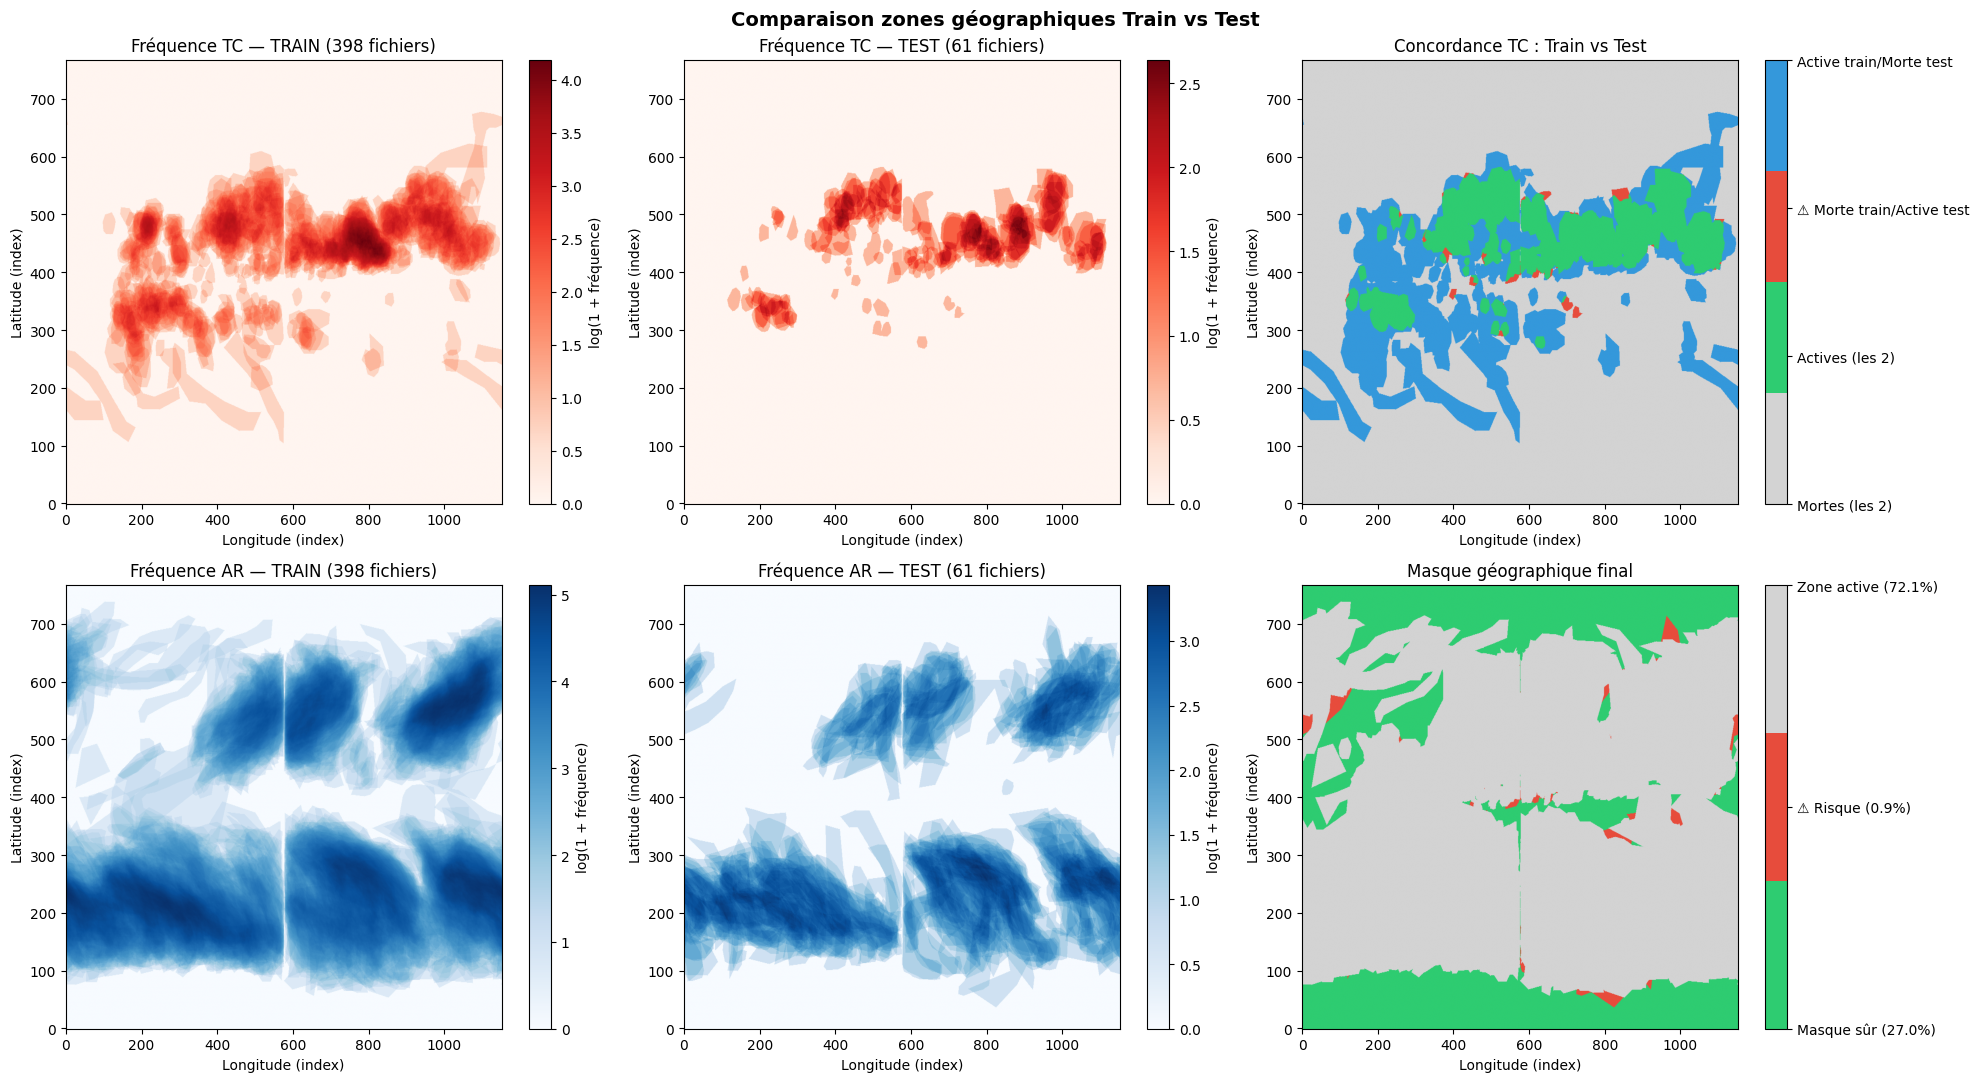


✅ Visualisation sauvegardée dans train_test_geographic_comparison.png


In [9]:
# ============================================================
# ÉTAPE 5 — Visualisations
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Comparaison zones géographiques Train vs Test', fontsize=14, fontweight='bold')
 
# 1. Fréquence TC train
im1 = axes[0, 0].imshow(np.log1p(count_tc_train), origin='lower', cmap='Reds', aspect='auto')
plt.colorbar(im1, ax=axes[0, 0], label='log(1 + fréquence)')
axes[0, 0].set_title(f'Fréquence TC — TRAIN ({n_train} fichiers)')
 
# 2. Fréquence TC test
im2 = axes[0, 1].imshow(np.log1p(count_tc_test), origin='lower', cmap='Reds', aspect='auto')
plt.colorbar(im2, ax=axes[0, 1], label='log(1 + fréquence)')
axes[0, 1].set_title(f'Fréquence TC — TEST ({n_test} fichiers)')
 
# 3. Zones mortes train vs test (TC)
diff_tc = np.zeros(SHAPE, dtype=np.int8)
diff_tc[(count_tc_train == 0) & (count_tc_test == 0)] = 0   # mortes dans les deux
diff_tc[(count_tc_train >  0) & (count_tc_test >  0)] = 1   # actives dans les deux
diff_tc[(count_tc_train == 0) & (count_tc_test >  0)] = 2   # ⚠️ morte train / active test
diff_tc[(count_tc_train >  0) & (count_tc_test == 0)] = 3   # active train / morte test
 
cmap_diff = mcolors.ListedColormap(['#d3d3d3', '#2ecc71', '#e74c3c', '#3498db'])
im3 = axes[0, 2].imshow(diff_tc, origin='lower', cmap=cmap_diff, aspect='auto', vmin=0, vmax=3)
cbar3 = plt.colorbar(im3, ax=axes[0, 2], ticks=[0, 1, 2, 3])
cbar3.set_ticklabels(['Mortes (les 2)', 'Actives (les 2)', '⚠️ Morte train/Active test', 'Active train/Morte test'])
axes[0, 2].set_title('Concordance TC : Train vs Test')
 
# 4. Fréquence AR train
im4 = axes[1, 0].imshow(np.log1p(count_ar_train), origin='lower', cmap='Blues', aspect='auto')
plt.colorbar(im4, ax=axes[1, 0], label='log(1 + fréquence)')
axes[1, 0].set_title(f'Fréquence AR — TRAIN ({n_train} fichiers)')
 
# 5. Fréquence AR test
im5 = axes[1, 1].imshow(np.log1p(count_ar_test), origin='lower', cmap='Blues', aspect='auto')
plt.colorbar(im5, ax=axes[1, 1], label='log(1 + fréquence)')
axes[1, 1].set_title(f'Fréquence AR — TEST ({n_test} fichiers)')
 
# 6. Masque sûr final
cmap_mask = mcolors.ListedColormap(['#2ecc71', '#e74c3c', '#d3d3d3'])
mask_viz = np.zeros(SHAPE, dtype=np.int8)
mask_viz[safe_mask] = 0                          # vert  = masque sûr
mask_viz[dead_in_train_active_in_test] = 1       # rouge = danger
mask_viz[~never_event_train] = 2                 # gris  = zone active train
im6 = axes[1, 2].imshow(mask_viz, origin='lower', cmap=cmap_mask, aspect='auto', vmin=0, vmax=2)
cbar6 = plt.colorbar(im6, ax=axes[1, 2], ticks=[0, 1, 2])
cbar6.set_ticklabels([f'Masque sûr ({100*safe_mask.mean():.1f}%)',
                       f'⚠️ Risque ({100*dead_in_train_active_in_test.mean():.1f}%)',
                       f'Zone active ({100*(~never_event_train).mean():.1f}%)'])
axes[1, 2].set_title('Masque géographique final')
 
for ax in axes.flat:
    ax.set_xlabel('Longitude (index)')
    ax.set_ylabel('Latitude (index)')
 
plt.tight_layout()
plt.savefig('train_test_geographic_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Visualisation sauvegardée dans train_test_geographic_comparison.png')